In [1]:
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "12"
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
iris = load_iris()

In [4]:
X = iris.data
y = iris.target

<Axes: >

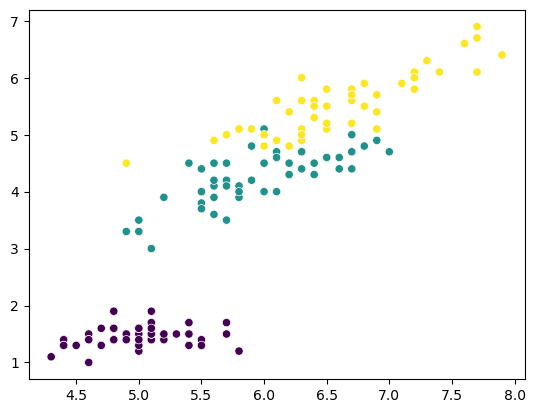

In [5]:
# Visualize
sns.scatterplot(x=X[:,0], y=X[:,2], c=y)

In [6]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

<Axes: >

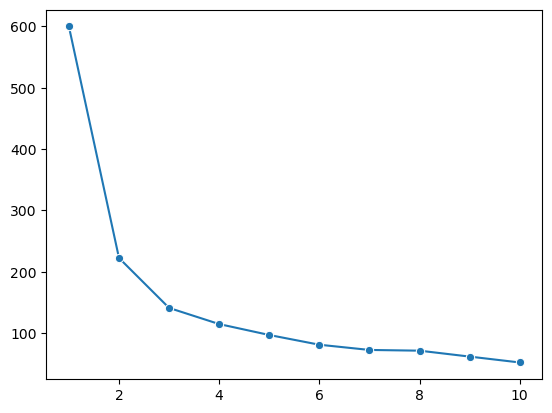

In [11]:
sns.lineplot(x=range(1, 11), y=wcss, marker="o")

<Axes: >

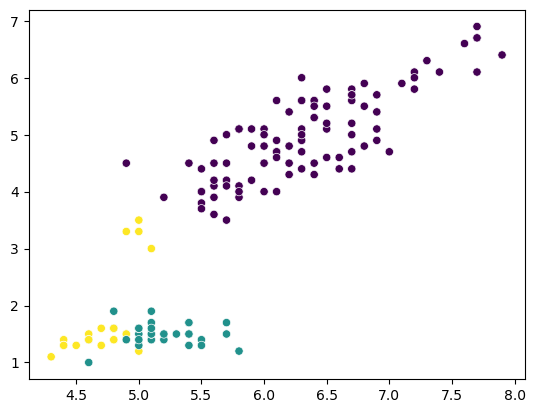

In [9]:
# KMeans

model = KMeans(
    n_clusters=3,
    random_state=42
)

labels = model.fit_predict(X_scaled)

sns.scatterplot(
    x=X[:,0],
    y=X[:,2],
    c=labels
)